# Setup
## Ustawienie

In [1]:
environment = 'Colab'
cross_validation_splitter_strategy = 5
reproducible_randomization_seed = 420
optuna_trial_count = 150
optima_renderer_mode="colab"

## Importowanie Bibliotek

In [2]:
import pandas as pd
if environment == 'Colab':
    !pip install optuna
from optuna import create_study, visualization as optuna_vis
from optuna.samplers import TPESampler
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.dummy import DummyClassifier
from sklearn.preprocessing import RobustScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from pathlib import Path


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 265.9/265.9 kB 10.6 MB/s eta 0:00:00


## Pomocne Funkcje

In [3]:
def barchart_record_count_by_category_value(dataframe, category_column_name):
    # Set visual style
    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(6, 5))

    # Create count plot for the 'Survived' column
    ax = sns.countplot(
        data=titanic_df,
        x=f"{category_column_name}",
        hue=f"{category_column_name}",
        palette={0: "#e74c3c", 1: "#2ecc71"},
        legend=False,
    )

    # Customize labels and title
    plt.title(
        f"Record Count by Category: {category_column_name}", fontsize=14, fontweight="bold", pad=15
    )
    plt.xlabel("Category Values", fontsize=12)
    plt.ylabel("Record Count", fontsize=12)


    # Add numeric annotations inside bars
    for p in ax.patches:
        height = int(p.get_height())
        if height > 0:
            ax.annotate(
                f"{height}",
                (p.get_x() + p.get_width() / 2.0, height / 2),
                ha="center",
                va="center",
                fontsize=11,
                color="white",
                fontweight="bold",
            )

    plt.tight_layout()
    plt.show()

def get_scoring_metrics(expected_values, predicted_values):
    accuracy = accuracy_score(expected_values, predicted_values)
    f1score = f1_score(expected_values, predicted_values)
    _, _, _, false_positives = confusion_matrix(expected_values, predicted_values).ravel()
    return accuracy, f1score, false_positives



## Ładowanie Danych

In [4]:
environments = ['Local', 'Colab']

if environment not in environments:
    print("Environment Invalid!")

elif environment == 'Local':
    base_path = Path("02_podstawy_aiml") # change to path folder with data

elif environment == 'Colab':
    from google.colab import drive # remove the cell if not using colab
    drive.mount('/content/drive')
    base_path = Path("./drive/MyDrive/Solvro/")

titanic_df = pd.read_csv( base_path / 'titanic_analyzed.csv')
print(titanic_df.info())

Mounted at /content/drive
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 21 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    bool   
 2   Age          891 non-null    float64
 3   Fare         891 non-null    float64
 4   Family       891 non-null    int64  
 5   IsMale       891 non-null    bool   
 6   Embarked_C   891 non-null    bool   
 7   Embarked_Q   891 non-null    bool   
 8   Embarked_S   891 non-null    bool   
 9   Location_A   891 non-null    bool   
 10  Location_B   891 non-null    bool   
 11  Location_C   891 non-null    bool   
 12  Location_D   891 non-null    bool   
 13  Location_E   891 non-null    bool   
 14  Location_F   891 non-null    bool   
 15  Location_G   891 non-null    bool   
 16  Location_T   891 non-null    bool   
 17  Location_U   891 non-null    bool   
 18  Pclass_1     891 non-nul

Za wczasu usunę jeszcze kolumnę `PassengerId`:

In [5]:
titanic_df = titanic_df.drop('PassengerId', axis='columns')
print(titanic_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 20 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Survived    891 non-null    bool   
 1   Age         891 non-null    float64
 2   Fare        891 non-null    float64
 3   Family      891 non-null    int64  
 4   IsMale      891 non-null    bool   
 5   Embarked_C  891 non-null    bool   
 6   Embarked_Q  891 non-null    bool   
 7   Embarked_S  891 non-null    bool   
 8   Location_A  891 non-null    bool   
 9   Location_B  891 non-null    bool   
 10  Location_C  891 non-null    bool   
 11  Location_D  891 non-null    bool   
 12  Location_E  891 non-null    bool   
 13  Location_F  891 non-null    bool   
 14  Location_G  891 non-null    bool   
 15  Location_T  891 non-null    bool   
 16  Location_U  891 non-null    bool   
 17  Pclass_1    891 non-null    bool   
 18  Pclass_2    891 non-null    bool   
 19  Pclass_3    891 non-null    b

## Skrót Obróbki Danych
To zrobiłem z danymi:
* `Name` i `Ticket` dropnąłem bez żadnych ekstrakcji
*  Z `Cabin` dokonałem ekstrakcji pierwszej litery w sekwencji i zastąpiłem kolumną `Location`
*  `Parch` i `SibSp` zsumowałem i zastąpiłem kolumną `Family`
* `Sex` zredukowałem do biarnej flagi `IsMale`
* `Embarked`, `Location` oraz `Pclass` encodowałem metodą one-hot
* `Fare` - zważając na outliery - transformowałem logarytmicznie w celach unormalnienia dystrybucji

## Wyniki Analizy

*Czego nauczyło Cię o badanym zbiorze danych poprzednie zadanie? Jak możesz wykorzystać wyciągnięte z niego wnioski w procesie tworzenia modelu?*

To udało mi się wydedukować:
- jeśli jesteś memszczyzną to według modelu masz o wiele mniejsze szansy przeżycia
- im wyższa klasa pasażerska (im niższa wartość `Pclass`) tym większa szansa na przeżycie
- im droższy miałeś bilet, tym bardziej prawdopodone że przeżyłeś
- najbardziej sprzyjająca lokalizacja do przetrwania katastrofy to 'B'
# Tworzenie Modelu
## Uwaga: Niezbalansowane dane

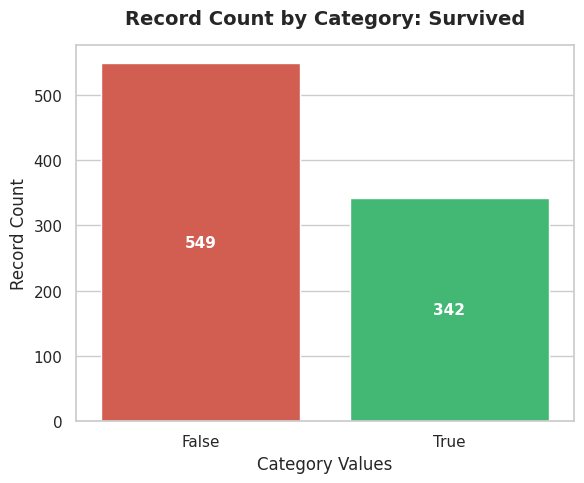

In [6]:
barchart_record_count_by_category_value(titanic_df, 'Survived')

Będzie to potrzebne podczas rozpatrywania modeli *DummyClassifier*
## Jaki Rodzaj ML użyć?
Nasze dane mają etykiety w postaci `Survived`, zatem nasz model należeć będzie do dziedziny **uczenia nadzorowanego**.
Ponadto, wymagamy wartości nie ciągłej, a dyskretnej (przydzielić record do danej klasy), zatem będzie to zadanie **klasyfikacji**.
Zatem mamy do wyboru modele:
* Regresja Logistyczna
* Drzewa / Lasy Decyzyjne
* Support Vector Machines
* MLP
* K-Nearest Neigbhour
* XGBoost
( i jeszcze DummyClassifier)

Rozważę następujące modele:
* *Regresja Logistyczna*
* `???`

## Jakie Metryki?
* `accurary` - klasyk
* `F1-score` - kompensuje niezbalansowanie datasetu, a z takim właśnie pracujemy
* `False-Positive` - jeśli model ma mi przewidzieć, czy nie skończę jak Leonardo daVinci, to chciałbym wiedzieć jakie mam szanse że się pomylił

## Preparacja Datasetu do Treningu
### Separacja Etykiet od Predykatorów
Rolę etykiety (**target**) pełni kolumna `Survived`, więc rozdzielmy ją teraz od naszych predykatorów (**data**):

In [7]:
dataframe_data = titanic_df.drop(columns=['Survived']) # X
dataframe_target = titanic_df['Survived'] # y

### Podział Training|Testing

In [8]:
data_training, data_testing, target_training, target_testing = train_test_split(dataframe_data, dataframe_target, train_size=.8, random_state=reproducible_randomization_seed ,shuffle=True)

### Baseline: DummyClassifier

In [9]:
model = DummyClassifier(strategy="most_frequent")
model.fit(data_training, target_training)
target_prediction = model.predict(data_testing)
accuracy, f1score, false_positives = get_scoring_metrics(target_testing, target_prediction)
print(accuracy)
print(f1score)
print(false_positives)

results = cross_val_score(model, dataframe_data, dataframe_target, cv=cross_validation_splitter_strategy, scoring='accuracy')
print(f'Mean Accuracy: {results.mean()}')
results = cross_val_score(model, dataframe_data, dataframe_target, cv=cross_validation_splitter_strategy, scoring='f1')
print(f'Mean F1-Score: {results.mean()}')

0.5865921787709497
0.0
0
Mean Accuracy: 0.6161634548992531
Mean F1-Score: 0.0


Podczas gdy `accuracy` wprowadza jakąś użyteczną informacje, to niezbalansowanie datasetu + strategia mody
prowadzi nas do wyzerowania `F1-score` oraz `false_positives`.
`F1-score` jest trochę bardziej skomplikowany do wytłumaczenia,
natomiast `false_positives` == 0, gdyż dataset posiada więcej osób które nie przeżyły, zatem DummyClassifier
predykuje że nikt nie przeżyje - brak false-positiwów!.
Przez to że `Survived` ma więcej **0** niż **1**, to F1-score DummClassifiera musi być 0.

## Regresja Logistyczna

### Standaryzacja Danych
Przed trenowaniem modelu, muszę ustandaryzować dane - jest to specyficzne dla algorytmów takich jak regresja logistyczna.
Wybieram Robust Scaler, gdyż brzmi on jako najbardziej uniwersalny i bezbłędny (przede wszystkim odporny na outliery)

In [10]:
scaler = RobustScaler()
data_training_scaled = scaler.fit_transform(data_training)
data_testing_scaled = scaler.transform(data_testing)

### Trenowanie Modelu

In [11]:
model = LogisticRegression(random_state=reproducible_randomization_seed, class_weight='balanced')
model.fit(data_training_scaled, target_training)

LogisticRegression(class_weight='balanced', random_state=420)

### Predykcja Testowa

In [12]:
target_prediction = model.predict(data_testing_scaled)
accuracy, f1score, false_positives = get_scoring_metrics(target_testing, target_prediction)
print(accuracy)
print(f1score)
print(false_positives)

0.8491620111731844
0.8137931034482758
59


Jak widać, dla danego zbioru testowego model osiągnął celność *81%*.

### Cross-Validacja
Upewnijmy się że wynik ten nie jest wynikiem wylosowania łatwego zbioru testowego:

In [13]:
model = LogisticRegression(random_state=reproducible_randomization_seed)
results = cross_val_score(make_pipeline(RobustScaler(),model), dataframe_data, dataframe_target, cv=cross_validation_splitter_strategy, scoring='accuracy')
print(f'Mean Accuracy: {results.mean()}')
results = cross_val_score(make_pipeline(RobustScaler(),model), dataframe_data, dataframe_target, cv=cross_validation_splitter_strategy, scoring='f1')
print(f'Mean F1-Score: {results.mean()}')

Mean Accuracy: 0.8092210156299039
Mean F1-Score: 0.7408051891709441


Cross-Validacja potwierdziła, że wytrenowany model jest dość stabilny( wartości oscylują w małej odległości od centrum).

### Optymalizacja Hiperparametrów
Dla `LogisticRegression` hiperparametry - jakie będę optymalizować - to:
* `C` - (siła regularyzacji)^(-1), wartość kontrolująca konflikt: prostota vs overfitting modelu
    * rozpatruję zakres (0.0001, 1000)
* `l1_ratio` - minimalizuje wartość współczynników modelu, a wraz z tym skalę overfitting'u.
    * rozpatruję 2 wartości: **1** `l1` Lasso (absolutne wartości współczynników) oraz **0** `l2` Ridge (kwadraty wartości współczynników)
#### Funkcja Celu
Jako metrykę, którą będę maksymalizował, wybieram `F1-score`, gdyż jest to `accuracy` ale bardziej goated.

In [14]:
def evaluator(trial):
    regularization_strength = trial.suggest_float("C", 10**(-4), 10**(3), log=True)
    coefficient_penalty = trial.suggest_categorical("l1_ratio", [0, 1])

    model = LogisticRegression(
        C=regularization_strength,
        l1_ratio=coefficient_penalty,
        random_state=reproducible_randomization_seed,
        class_weight='balanced',
        max_iter=2000,
        solver='saga' # else study fails with value error.
        )
    pipeline = make_pipeline(RobustScaler(), model)
    return cross_val_score(pipeline, dataframe_data, dataframe_target, cv=cross_validation_splitter_strategy, scoring='f1').mean()

#### Tworzenie Study
Framework optymalizacji hiperparametrów jaki użyję to Optuna.

In [15]:
sampler = TPESampler(seed=reproducible_randomization_seed)
study = create_study(direction="maximize", sampler=sampler)
study.optimize(evaluator, optuna_trial_count)

[I 2026-08-18 05:10:49,465] A new study created in memory with name: no-name-2538b362-ec1b-4516-ac87-d19bf4dc7f37
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when 

#### Wyniki Optymalizacji

In [16]:
print(f"Best Trial F1-Score: {study.best_value}")
print("Best Hyperparameters:")
for key, value in study.best_params.items():
    print(f"  {key}: {value}")

Best Trial F1-Score: 0.7471368614129867
Best Hyperparameters:
  C: 0.10379827264183022
  l1_ratio: 0


Dla mojego modelu Regresji Logistycznej najlepszy okazał się penalty typu *Ridge*, a także C=~0.102
#### Wizualizacje

In [17]:
fig_history = optuna_vis.plot_optimization_history(study)
fig_history.show(renderer=optima_renderer_mode)

![OUTPUT](./optuna-logistical_regression-output.png)

Widzimy, iż optuna znalazła bardzo optymalne rozwiązanie już na początku, a potem małymi sukcesami je poprawiała.
## XGBoost
XGBoost nie potrzebuje standaryzacji danych.
### Trenowanie Modelu

In [18]:
model = XGBClassifier(random_state=reproducible_randomization_seed, eval_metric='logloss')
model.fit(data_training, target_training)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

### Predykcja Testowa

In [19]:
target_prediction = model.predict(data_testing)
accuracy, f1score, false_positives = get_scoring_metrics(target_testing, target_prediction)
print(accuracy)
print(f1score)
print(false_positives)

0.8715083798882681
0.8368794326241135
59


### Cross-Validacja

In [20]:
model = XGBClassifier(random_state=reproducible_randomization_seed)
results = cross_val_score(model, dataframe_data, dataframe_target, cv=cross_validation_splitter_strategy, scoring='accuracy')
print(f'Mean Accuracy: {results.mean()}')
results = cross_val_score(model, dataframe_data, dataframe_target, cv=cross_validation_splitter_strategy, scoring='f1')
print(f'Mean F1-Score: {results.mean()}')

Mean Accuracy: 0.8204695248258114
Mean F1-Score: 0.758468986674336


### Optymalizacja Hiperparametrów
Dla `XGBClassifier` hiperparametry - jakie będę optymalizować - to:
* `max_depth` - głębokość drzewa, głębsze drzewa grożą overfitting'iem
    * rozpatruję zakres (2, 10)
* `learning_rate` - skala kontrybucji drzew do ostatecznego wyniku, niska wartość oznacza lepszą generalizację i mniejszy overfitting
    * rozpatruję zakres (0.005, 3)
* `n_estimators` - liczba drzew do wygenerowania
    * rozpatruję zakres (100, 1500)
#### Funkcja Celu
Jako metrykę, którą będę maksymalizował, wybieram `F1-score`, gdyż jest to `accuracy` ale bardziej goated.

In [21]:
def evaluator(trial):
    maximal_tree_depth = trial.suggest_int("max_depth", 2, 10)
    number_of_trees = trial.suggest_int("n_estimators", 100, 1500, step=100)
    individual_tree_impact = trial.suggest_float("learning_rate", 0.005, 3, log=True)

    model = XGBClassifier(
        max_depth=maximal_tree_depth,
        n_estimators=number_of_trees,
        learning_rate=individual_tree_impact,
        random_state=reproducible_randomization_seed,
        )
    return cross_val_score(model, dataframe_data, dataframe_target, cv=cross_validation_splitter_strategy, scoring='f1').mean()

#### Tworzenie Study
Framework optymalizacji hiperparametrów jaki użyję to Optuna.

In [22]:
sampler = TPESampler(seed=reproducible_randomization_seed)
study = create_study(direction="maximize", sampler=sampler)
study.optimize(evaluator, optuna_trial_count)

[I 2026-08-18 05:12:27,477] A new study created in memory with name: no-name-0700cf03-8cae-4649-8e72-56c28668c942
[I 2026-08-18 05:12:28,833] Trial 0 finished with value: 0.7732500344114258 and parameters: {'max_depth': 4, 'n_estimators': 700, 'learning_rate': 0.027585897272002117}. Best is trial 0 with value: 0.7732500344114258.
[I 2026-08-18 05:12:30,608] Trial 1 finished with value: 0.754810698223107 and parameters: {'max_depth': 2, 'n_estimators': 1400, 'learning_rate': 0.28083489738233014}. Best is trial 0 with value: 0.7732500344114258.
[I 2026-08-18 05:12:31,128] Trial 2 finished with value: 0.7656215847308105 and parameters: {'max_depth': 5, 'n_estimators': 200, 'learning_rate': 0.27483161143786083}. Best is trial 0 with value: 0.7732500344114258.
[I 2026-08-18 05:12:31,924] Trial 3 finished with value: 0.7438104331789492 and parameters: {'max_depth': 7, 'n_estimators': 200, 'learning_rate': 0.0071930356522816544}. Best is trial 0 with value: 0.7732500344114258.
[I 2026-08-18 0

#### Wyniki Optymalizacji

In [23]:
print(f"Best Trial F1-Score: {study.best_value}")
print("Best Hyperparameters:")
for key, value in study.best_params.items():
    print(f"  {key}: {value}")

Best Trial F1-Score: 0.7762312880193756
Best Hyperparameters:
  max_depth: 7
  n_estimators: 500
  learning_rate: 0.008263440532531871


Dla mojego modelu XGBoosted Trees najlepiej spisało się 7 głębokości drzewa, 500 drew i niski `learning_rate`
#### Wizualizacje

In [24]:
fig_history = optuna_vis.plot_optimization_history(study)
fig_history.show(renderer=optima_renderer_mode)

![OUTPUT](./optuna-xdgboost-output.png)

Widzimy, iż optuna znalazła bardzo optymalne rozwiązanie już na początku, a potem małymi sukcesami je poprawiała - tak samo jak przy modelu regresji logistycznej.

## Wnioski
Można się cieszyć - oba modele wyprzedzają `DummyClassifier` (*dzięki Bogu*)! Z tego tytułu  wyniki klasyfikacji obu modeli uznaję za *dobre*.
Patrząc jedynie przez przymat `accuracy`, modele są lepsze od małpiego wybierania mody zbioru danych o **~20pkt%**.

Model `XGBClassifier` wyprzedza `LogisticRegression` w `accuracy` oraz `F1-score` - lecz *nieznacznie*.
Dla określonego przeze mnie zbioru treningowego oraz testowego oba modele wyrzuciły tyle samo `false_positives`.

Krótko mówiąc: `XGBClassifier` wygrywa w *celności* oraz wyważeniu *precyzji* vs *recall*'u.

Cross-Validacja pomogła mi potwierdzić stabilność obu modeli.

Optymalizacja Hiperparametrów wiązała się z poprawieniem sprawności modelu.
Jednakże muszę przyznać, iż patrząc na dość znikome zyski w evaluacji modeli po fine-tuningu, uważam iż fine-tuning nie miał zbyt wielkiego sensu.
Dochodzę do wniosku, iż dataset - z jakim miałem do czynienia - był nie wystarczająco przerobiony / na tyle podstawowy, iż domyślne wartości hiperparametrów zbliżone były do najbardziej optymalnych.